## Predicting Student GPA through Lifestyle and Behavioral Factors 
#### By Erika Roa and Aisling Beresford

### Data Collection

In [2]:
#imports the zipfile module to extract compressed files and unzips the dataset into a folder named 'data'
import zipfile

with zipfile.ZipFile('Final Exam Data.zip', 'r') as zip_ref:
    zip_ref.extractall('data')

#imports os module to interact with the file system and lists extracted files to confirm successful extraction
import os
os.listdir('data')

['.ipynb_checkpoints',
 'student_lifestyle_dataset..csv',
 'student_lifestyle_dataset.csv']

In [3]:
#reads the CSV file into a pandas dataframe and displays the first few rows
import pandas as pd

df = pd.read_csv('data/student_lifestyle_dataset.csv')
df.head()

,Student_ID,Study_Hours_Per_Day,Extracurricular_Hours_Per_Day,Sleep_Hours_Per_Day,Social_Hours_Per_Day,Physical_Activity_Hours_Per_Day,Stress_Level,Gender,Grades
0,1,6.9,3.8,8.7,2.8,1.8,Moderate,Male,7.48
1,2,5.3,3.5,8.0,4.2,3.0,Low,Female,6.88
2,3,5.1,3.9,9.2,1.2,4.6,Low,Male,6.68
3,4,6.5,2.1,7.2,1.7,6.5,Moderate,Male,7.20
4,5,8.1,0.6,6.5,2.2,6.6,High,Male,8.78


### Understanding Data + Quality Check

In [4]:
#displays information about the dataset including column names, data types, and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Student_ID                       2000 non-null   int64  
 1   Study_Hours_Per_Day              2000 non-null   float64
 2   Extracurricular_Hours_Per_Day    2000 non-null   float64
 3   Sleep_Hours_Per_Day              2000 non-null   float64
 4   Social_Hours_Per_Day             2000 non-null   float64
 5   Physical_Activity_Hours_Per_Day  2000 non-null   float64
 6   Stress_Level                     2000 non-null   object 
 7   Gender                           2000 non-null   object 
 8   Grades                           2000 non-null   float64
dtypes: float64(6), int64(1), object(2)
memory usage: 140.8+ KB


In [5]:
#checks for missing values in each column of the dataset
df.isnull().sum()

Student_ID                         0
Study_Hours_Per_Day                0
Extracurricular_Hours_Per_Day      0
Sleep_Hours_Per_Day                0
Social_Hours_Per_Day               0
Physical_Activity_Hours_Per_Day    0
Stress_Level                       0
Gender                             0
Grades                             0
dtype: int64

There are no missing values in the dataset, so cleaning is unnecessary 

### Descriptive Statistics

In [6]:
#displays summary statistics for all numeric variables in the dataset
df.describe()

,Student_ID,Study_Hours_Per_Day,Extracurricular_Hours_Per_Day,Sleep_Hours_Per_Day,Social_Hours_Per_Day,Physical_Activity_Hours_Per_Day,Grades
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000
mean,1000.500000,7.475800,1.990100,7.501250,2.704550,4.32830,7.789825
std,577.494589,1.423888,1.155855,1.460949,1.688514,2.51411,0.746777
min,1.000000,5.000000,0.000000,5.000000,0.000000,0.00000,5.600000
25%,500.750000,6.300000,1.000000,6.200000,1.200000,2.40000,7.250000
50%,1000.500000,7.400000,2.000000,7.500000,2.600000,4.10000,7.780000
75%,1500.250000,8.700000,3.000000,8.800000,4.100000,6.10000,8.320000
max,2000.000000,10.000000,4.000000,10.000000,6.000000,13.00000,10.000000


No outliers were removed, because they were considered valid variations rather than errors in data entry

### Displaying Data

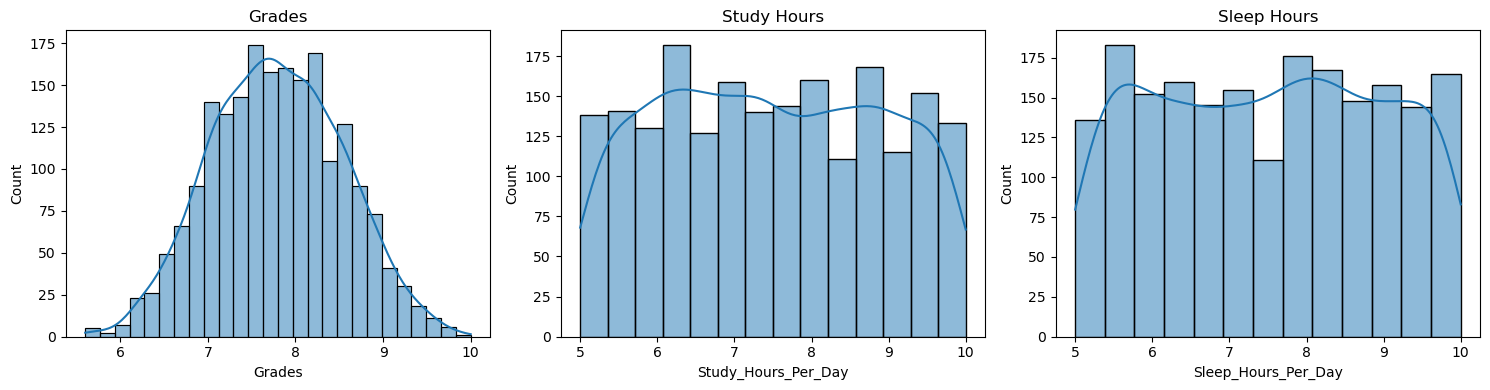

In [7]:
#creates histograms for Grades, Study Hours, and Sleep Hours
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(df['Grades'], kde=True, ax=axes[0])
axes[0].set_title("Grades")

sns.histplot(df['Study_Hours_Per_Day'], kde=True, ax=axes[1])
axes[1].set_title("Study Hours")

sns.histplot(df['Sleep_Hours_Per_Day'], kde=True, ax=axes[2])
axes[2].set_title("Sleep Hours")

plt.tight_layout()
plt.show()

Histograms were used to evaluate the distribution of key variables. Grades appeared relatively normally distributed, while study and sleep hours showed slight variation but no extreme skewness.

In [8]:
#calculates skewness to evaluate the symmetry of distributions for selected variables
df[['Grades','Study_Hours_Per_Day','Sleep_Hours_Per_Day']].skew()

Grades                 0.027582
Study_Hours_Per_Day    0.034988
Sleep_Hours_Per_Day   -0.007096
dtype: float64

<Axes: xlabel='Physical_Activity_Hours_Per_Day'>

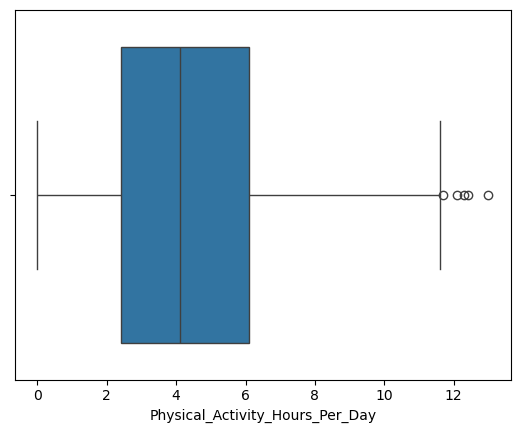

In [9]:
#creates a boxplot to visualize potential outliers in physical activity hours per day
import seaborn as sns
sns.boxplot(x=df['Physical_Activity_Hours_Per_Day'])

This boxplot shows the distribution of physical activity hours per day and is used to identify potential outliers in the dataset. One high value is observed but was retained as it may represent valid variation in student behavior.

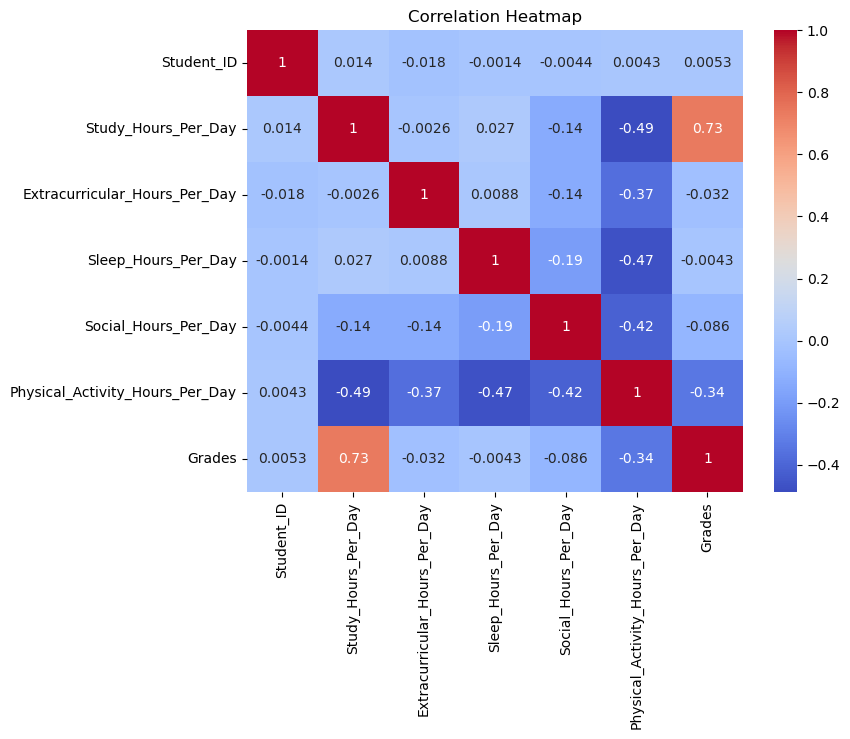

In [10]:
#creates a heatmap to show correlations between all numeric variables in the dataset

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

A correlation heatmap was used to evaluate relationships between numerical variables. A positive relationship was observed between study hours and grades, suggesting that increased study time is associated with higher academic performance. Other variables showed weaker correlations with grades.

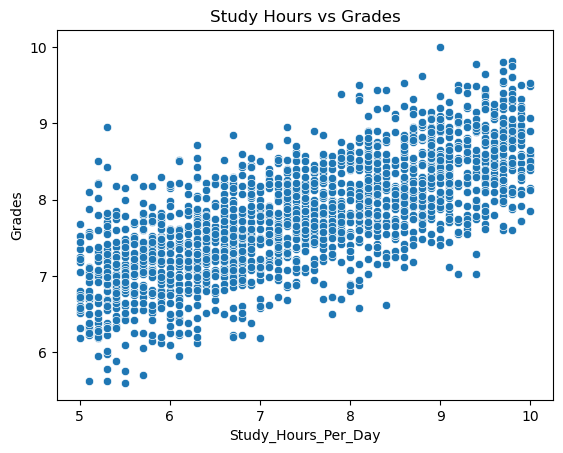

In [11]:
#creates a scatter plot to show the relationship between study hours and grades
sns.scatterplot(x=df['Study_Hours_Per_Day'], y=df['Grades'])
plt.title("Study Hours vs Grades")
plt.show()

This scatterplot shows the relationship between study hours and academic performance (Grades). The plot suggests a positive trend, indicating that students who study more hours per day tend to achieve higher grades.

## Regression Model: Predicting Student Grades

In [12]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

features = ['Study_Hours_Per_Day', 'Sleep_Hours_Per_Day', 
            'Physical_Activity_Hours_Per_Day', 'Social_Hours_Per_Day', 
            'Extracurricular_Hours_Per_Day']

X = df[features]
y = df['Grades']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("R² Score:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

R² Score: 0.5496898072072273
MSE: 0.26291997541829354


## Conclusion

This analysis explored how lifestyle factors influence student academic performance. The correlation heatmap revealed that study hours had the strongest positive relationship with grades, while stress level showed a negative correlation. The linear regression model achieved an R² score of 0.55, meaning lifestyle factors alone explain approximately 55% of the variance in student grades.
These findings suggest that students looking to improve academic performance should prioritize study habits and sleep consistency. The remaining 45% of variance likely reflects factors not captured in this dataset, such as attendance, prior academic history, or course difficulty.